# Deliverable 4: Focal Loss + Class Weights (Improvement 3)
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS

**Group:** 7 | **Members:** 26100098, 26100392  
**Improvement:** Dice + CrossEntropy  →  Dice + Focal Loss (with inverse-frequency class weights)  
**Baseline reference:** D3 clean-label 2D U-Net (Liver: 0.888, Tumor: 0.474 @ epoch 14)  
**Goal:** Attack class imbalance directly — down-weight easy background pixels, focus gradient on rare tumor pixels.  
**Everything else is identical to D3** (model, split, optimizer, schedule, seed). Only the loss changes. This is a controlled single-variable experiment.

## 1. Installs and Imports

In [1]:
import os
import re
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import nibabel as nib
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using MPS (M4 GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using CUDA')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch: {torch.__version__}')

Using MPS (M4 GPU)
PyTorch: 2.11.0


## 2. Configuration

**Only change `DATA_DIR` if your folder is in a different location.**

All hyperparameters match D3 exactly except the loss function. Image size stays at 128×128, batch size 16, 30 epochs, LR 1e-4. This keeps the comparison clean — any change in results is attributable to the loss swap.

In [2]:
# import os, glob

# DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

# all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
# print(f'Found {len(all_nii)} .nii files total')

# vol_files = [p for p in all_nii if 'volume'       in os.path.basename(p).lower()]
# seg_files = [p for p in all_nii if 'segmentation' in os.path.basename(p).lower()]

# if vol_files and seg_files:
#     VOL_DIR = os.path.dirname(vol_files[0])
#     SEG_DIR = os.path.dirname(seg_files[0])
# else:
#     print("fallback")
#     candidates = [
#         (os.path.join(DATA_DIR, 'volumes'),         os.path.join(DATA_DIR, 'segmentations')),
#         (os.path.join(DATA_DIR, 'volume'),          os.path.join(DATA_DIR, 'segmentation')),
#         (os.path.join(DATA_DIR, 'imagesTr'),        os.path.join(DATA_DIR, 'labelsTr')),
#     ]
#     VOL_DIR, SEG_DIR = next(((v, s) for v, s in candidates if os.path.exists(v) and os.path.exists(s)),
#                              (DATA_DIR, DATA_DIR))

# IMG_SIZE       = 128
# BATCH_SIZE     = 16
# NUM_EPOCHS     = 20
# LR             = 1e-4
# HU_MIN, HU_MAX = -100, 400

# print(f'Volumes folder:       {VOL_DIR}')
# print(f'Segmentations folder: {SEG_DIR}')
# print(f'Volume .nii files:       {len(vol_files)}')
# print(f'Segmentation .nii files: {len(seg_files)}')
# if vol_files:
#     print(f'Sample volume: {os.path.basename(vol_files[0])}')
# if seg_files:
#     print(f'Sample seg:    {os.path.basename(seg_files[0])}')

import os, glob, re

DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
all_volumes = [p for p in all_nii if 'volume'       in os.path.basename(p).lower()]
all_segs    = [p for p in all_nii if 'segmentation' in os.path.basename(p).lower()]

print(f'Found {len(all_volumes)} volume files (across all pt folders)')
print(f'Found {len(all_segs)} segmentation files')

IMG_SIZE       = 128
BATCH_SIZE     = 16
NUM_EPOCHS     = 20
LR             = 1e-4
HU_MIN, HU_MAX = -100, 400

Found 51 volume files (across all pt folders)
Found 131 segmentation files


## 3. Data Loading

Match `volume-X.nii` with `segmentation-X.nii` by case ID. LiTS label encoding:
- `0` = Background
- `1` = Liver  
- `2` = Tumor

In [ ]:
# def load_lits_paths(vol_dir, seg_dir):
#     vol_files = sorted(glob.glob(os.path.join(vol_dir, 'volume*.nii*')))
#     seg_files = sorted(glob.glob(os.path.join(seg_dir, 'segmentation*.nii*')))

#     def case_id(path):
#         m = re.search(r'(\d+)', os.path.basename(path))
#         return int(m.group(1)) if m else None

#     vol_map = {case_id(p): p for p in vol_files if case_id(p) is not None}
#     seg_map = {case_id(p): p for p in seg_files if case_id(p) is not None}
#     common  = sorted(set(vol_map).intersection(seg_map))

#     if len(common) == 0:
#         raise FileNotFoundError(
#             f'No matched pairs found.\nVol dir: {vol_dir}\nSeg dir: {seg_dir}\n'
#             f'Vol files found: {len(vol_files)} | Seg files found: {len(seg_files)}'
#         )

#     vol_paths = [vol_map[i] for i in common]
#     seg_paths = [seg_map[i] for i in common]
#     print(f'Found {len(vol_paths)} matched volume-segmentation pairs')
#     return vol_paths, 




# volume_paths, seg_paths = load_lits_paths(VOL_DIR, SEG_DIR)
def load_lits_paths(data_dir):
    all_nii = glob.glob(os.path.join(data_dir, '**', '*.nii*'), recursive=True)
    vol_files = sorted(p for p in all_nii if 'volume'       in os.path.basename(p).lower())
    seg_files = sorted(p for p in all_nii if 'segmentation' in os.path.basename(p).lower())

    def case_id(path):
        m = re.search(r'(\d+)', os.path.basename(path))
        return int(m.group(1)) if m else None

    vol_map = {case_id(p): p for p in vol_files if case_id(p) is not None}
    seg_map = {case_id(p): p for p in seg_files if case_id(p) is not None}
    common  = sorted(set(vol_map).intersection(seg_map))

    if len(common) == 0:
        raise FileNotFoundError(
            f'No matched pairs found under {data_dir}\n'
            f'Vol files found: {len(vol_files)} | Seg files found: {len(seg_files)}'
        )

    vol_paths = [vol_map[i] for i in common]
    seg_paths = [seg_map[i] for i in common]
    print(f'Found {len(vol_paths)} matched volume-segmentation pairs')
    print(f'Volume files scanned: {len(vol_files)}  |  Seg files scanned: {len(seg_files)}')
    print(f'Sample: {os.path.basename(vol_paths[0])} <-> {os.path.basename(seg_paths[0])}')
    return vol_paths, seg_paths


volume_paths, seg_paths = load_lits_paths(DATA_DIR)

Found 51 matched volume-segmentation pairs
Volume files scanned: 51  |  Seg files scanned: 131
Sample: volume-0.nii <-> segmentation-0.nii


## 4. Train / Val / Test Split

Same seed (42) as D3 — so train/val/test volumes are **identical** across deliverables. This is critical for fair comparison: any Dice change comes from the loss, not from seeing different patients.

In [4]:
# 70/15/15 volume level split with seed=42
np.random.seed(SEED)
n       = len(volume_paths)
indices = np.random.permutation(n)

train_idx = indices[:int(0.70 * n)]
val_idx   = indices[int(0.70 * n):int(0.85 * n)]
test_idx  = indices[int(0.85 * n):]

train_vol = [volume_paths[i] for i in train_idx]
train_seg = [seg_paths[i]    for i in train_idx]
val_vol   = [volume_paths[i] for i in val_idx]
val_seg   = [seg_paths[i]    for i in val_idx]
test_vol  = [volume_paths[i] for i in test_idx]
test_seg  = [seg_paths[i]    for i in test_idx]

print(f'Train: {len(train_vol)} volumes')
print(f'Val:   {len(val_vol)} volumes')
print(f'Test:  {len(test_vol)} volumes')

Train: 35 volumes
Val:   8 volumes
Test:  8 volumes


## 5. Dataset Class

Extracts 2D axial slices from 3D NIfTI volumes. Key preprocessing:
- **HU windowing:** clip to [-100, 400] — the standard soft tissue window
- **Normalization:** rescale to [0, 1]
- **Slice filtering:** skip slices with no liver or tumor content
- **Resize:** all slices resized to 128×128

In [ ]:
# class LiTSNIfTIDataset(Dataset):
#     def __init__(self, volume_paths, seg_paths,
#                  img_size=128, hu_min=-100, hu_max=400,
#                  filter_background=True):
#         self.img_size = img_size
#         self.hu_min   = hu_min
#         self.hu_max   = hu_max
#         self.slices   = []  # (vol_path, seg_path, slice_idx)

#         print('Indexing slices (loading segmentations only)...')
#         for vol_path, seg_path in zip(volume_paths, seg_paths):
#             seg = nib.load(seg_path).get_fdata().astype(np.uint8)
#             n_slices = seg.shape[2]
#             for s in range(n_slices):
#                 if filter_background and not np.any(seg[:, :, s] > 0):
#                     continue
#                 self.slices.append((vol_path, seg_path, s))

#         print(f'Total usable slices: {len(self.slices)}')

#     def __len__(self):
#         return len(self.slices)

#     def __getitem__(self, idx):
#         vol_path, seg_path, s = self.slices[idx]

#         vol = nib.load(vol_path).get_fdata()
#         seg = nib.load(seg_path).get_fdata().astype(np.uint8)

#         ct        = vol[:, :, s].astype(np.float32)
#         seg_slice = seg[:, :, s].astype(np.int64)

#         # HU windowing + normalize to [0, 1]
#         ct = np.clip(ct, self.hu_min, self.hu_max)
#         ct = (ct - self.hu_min) / (self.hu_max - self.hu_min)

#         # Resize to fixed spatial size
#         h, w      = ct.shape
#         ct        = ndimage.zoom(ct,        (self.img_size / h, self.img_size / w), order=1)
#         seg_slice = ndimage.zoom(seg_slice, (self.img_size / h, self.img_size / w), order=0)

#         ct_tensor  = torch.from_numpy(ct.astype(np.float32)).unsqueeze(0)  # (1, H, W)
#         seg_tensor = torch.from_numpy(seg_slice.astype(np.int64))          # (H, W)
#         return ct_tensor, seg_tensor

#with in memory caching 
class LiTSNIfTIDataset(Dataset):
    def __init__(self, volume_paths, seg_paths,
                 img_size=128, hu_min=-100, hu_max=400,
                 filter_background=True):
        self.img_size = img_size
        self.hu_min   = hu_min
        self.hu_max   = hu_max
        self.slices   = []
        self._vol_cache = {}   
        self._seg_cache = {}

        print('Indexing slices (loading segmentations only)...')
        for vol_path, seg_path in zip(volume_paths, seg_paths):
            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            for s in range(seg.shape[2]):
                if filter_background and not np.any(seg[:, :, s] > 0):
                    continue
                self.slices.append((vol_path, seg_path, s))
        print(f'Total usable slices: {len(self.slices)}')

    def _get_vol(self, path):
        if path not in self._vol_cache:
            self._vol_cache[path] = nib.load(path).get_fdata().astype(np.float32)
        return self._vol_cache[path]

    def _get_seg(self, path):
        if path not in self._seg_cache:
            self._seg_cache[path] = nib.load(path).get_fdata().astype(np.uint8)
        return self._seg_cache[path]

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        vol_path, seg_path, s = self.slices[idx]
        vol = self._get_vol(vol_path)    
        seg = self._get_seg(seg_path)    

        ct        = vol[:, :, s]
        seg_slice = seg[:, :, s].astype(np.int64)

        # HU windowing + normalize to [0, 1]
        ct = np.clip(ct, self.hu_min, self.hu_max)
        ct = (ct - self.hu_min) / (self.hu_max - self.hu_min)

        # Resize to fixed spatial size
        h, w = ct.shape
        ct        = ndimage.zoom(ct,        (self.img_size / h, self.img_size / w), order=1)
        seg_slice = ndimage.zoom(seg_slice, (self.img_size / h, self.img_size / w), order=0)

        ct_tensor  = torch.from_numpy(ct.astype(np.float32)).unsqueeze(0)
        seg_tensor = torch.from_numpy(seg_slice.astype(np.int64))
        return ct_tensor, seg_tensor

In [6]:
print('Building datasets...')
train_dataset = LiTSNIfTIDataset(train_vol, train_seg, img_size=IMG_SIZE)
val_dataset   = LiTSNIfTIDataset(val_vol,   val_seg,   img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Building datasets...
Indexing slices (loading segmentations only)...
Total usable slices: 4614
Indexing slices (loading segmentations only)...
Total usable slices: 1116
Train batches: 289 | Val batches: 70


## 6. Sanity Check — Visualize a Sample

CT batch shape:        torch.Size([16, 1, 128, 128])
Mask batch shape:      torch.Size([16, 128, 128])
CT value range:        [0.000, 1.000]
Unique mask values:    [0, 1, 2]


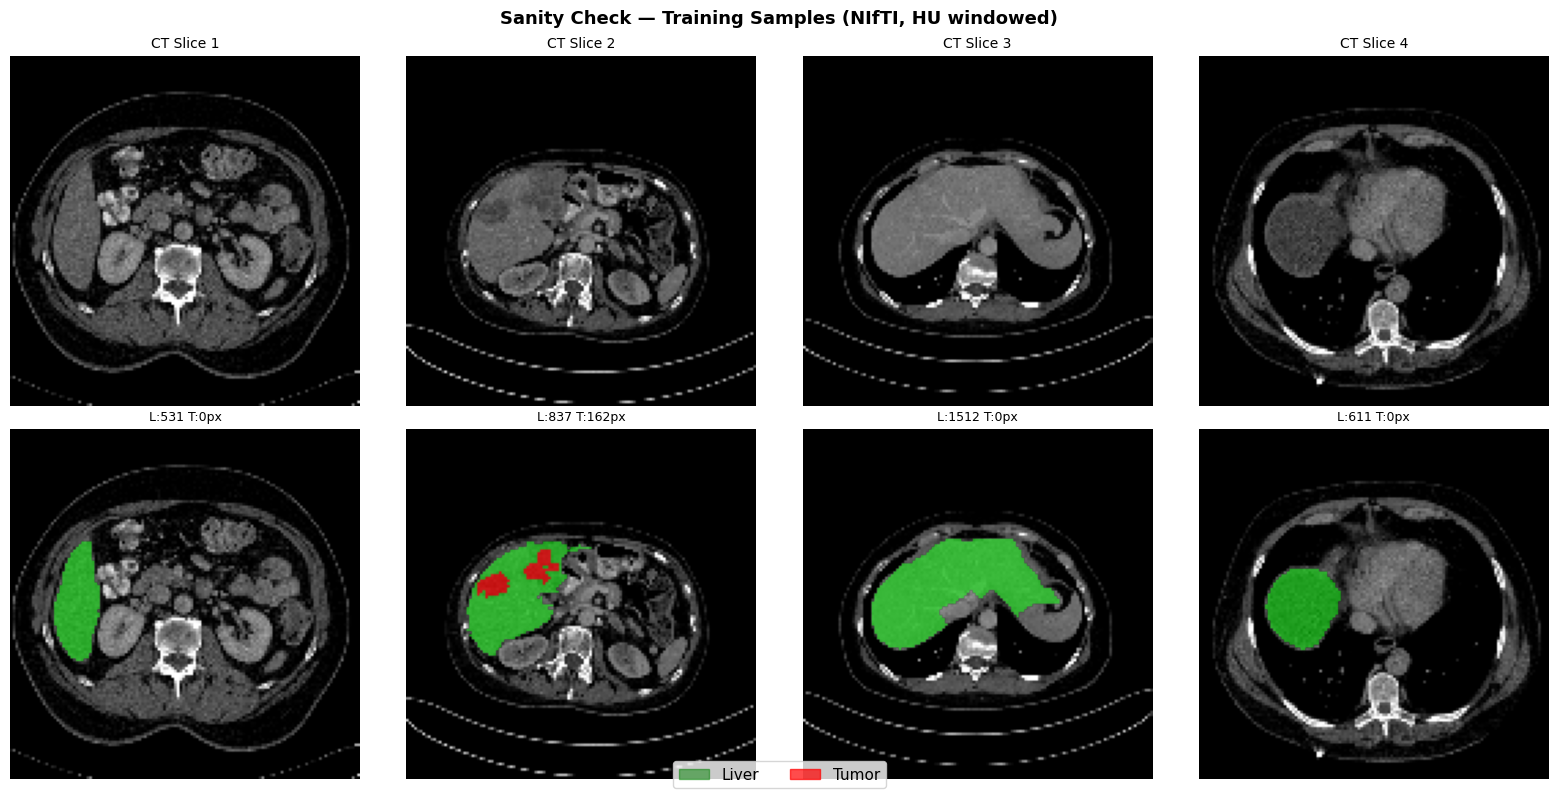

If liver (green) and tumor (red) overlays look correct, proceed to training.


In [7]:
ct_batch, seg_batch = next(iter(train_loader))
print(f'CT batch shape:        {ct_batch.shape}')
print(f'Mask batch shape:      {seg_batch.shape}')
print(f'CT value range:        [{ct_batch.min():.3f}, {ct_batch.max():.3f}]')
print(f'Unique mask values:    {seg_batch.unique().tolist()}')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    ct   = ct_batch[i, 0].numpy()
    mask = seg_batch[i].numpy()

    axes[0, i].imshow(ct.T, cmap='gray', origin='lower')
    axes[0, i].set_title(f'CT Slice {i+1}', fontsize=10)
    axes[0, i].axis('off')

    overlay = np.zeros((*ct.shape, 4))
    overlay[mask == 1] = [0, 1, 0, 0.5]
    overlay[mask == 2] = [1, 0, 0, 0.7]
    axes[1, i].imshow(ct.T, cmap='gray', origin='lower')
    axes[1, i].imshow(overlay.transpose(1, 0, 2), origin='lower')
    axes[1, i].set_title(f'L:{(mask==1).sum()} T:{(mask==2).sum()}px', fontsize=9)
    axes[1, i].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('Sanity Check — Training Samples (NIfTI, HU windowed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('If liver (green) and tumor (red) overlays look correct, proceed to training.')

## 7. 2D U-Net Architecture

Identical to D3. Standard encoder-decoder with skip connections.
- **Input:** (B, 1, 128, 128) — single-channel CT slice
- **Output:** (B, 3, 128, 128) — logits for background / liver / tumor
- **`base_features=64`** — standard U-Net capacity (~31M params)

In [ ]:
# 2D U-Net definition (ConvBlock + UNet2D) — unchanged from D3 so we're only testing the loss change.
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=1, num_classes=3, base_features=64):
        super().__init__()
        f = base_features

        # Encoder
        self.enc1 = ConvBlock(in_channels, f)
        self.enc2 = ConvBlock(f,    f*2)
        self.enc3 = ConvBlock(f*2,  f*4)
        self.enc4 = ConvBlock(f*4,  f*8)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(f*8, f*16)

        # Decoder
        self.up4  = nn.ConvTranspose2d(f*16, f*8, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(f*16, f*8)
        self.up3  = nn.ConvTranspose2d(f*8,  f*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(f*8,  f*4)
        self.up2  = nn.ConvTranspose2d(f*4,  f*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(f*4,  f*2)
        self.up1  = nn.ConvTranspose2d(f*2,  f,   kernel_size=2, stride=2)
        self.dec1 = ConvBlock(f*2,  f)

        self.out_conv = nn.Conv2d(f, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


model = UNet2D(in_channels=1, num_classes=3, base_features=64).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(f'Base features: 64 (standard U-Net capacity)')

Model parameters: 31,036,611
Base features: 64 (standard U-Net capacity)


## 8. Loss Function — **ONLY REAL CHANGE FROM D3**

Two changes:

**(a) Class weights (α)** — computed once from training pixels by inverse frequency. Background pixels outnumber tumor pixels ~200:1, so background gets a tiny weight and tumor gets a huge one. This stops the network from "winning" by predicting everything as background.

**(b) Focal loss (γ=2)** — the `(1 - p_t)^γ` term down-weights pixels the model is already confident about. An easy background pixel at 99% confidence contributes ~0.0001× its original loss. A hard tumor pixel at 20% confidence contributes ~0.64× its loss. **Gradient flows where it's needed.**

Combined with Dice loss (unchanged from D3), this is the full picture: Dice handles overlap-based imbalance, Focal forces attention on hard pixels, and class weights make rare classes count.

In [ ]:
# def compute_class_weights(dataset, num_classes=3, sample_frac=0.2):
#     """Count pixels per class on a random subset; weight = inverse frequency, normalized."""
#     counts = np.zeros(num_classes, dtype=np.float64)
#     n = len(dataset)
#     sample_size = max(1, int(n * sample_frac))
#     sample_idxs = np.random.choice(n, size=sample_size, replace=False)
#     for i in sample_idxs:
#         _, seg = dataset[i]
#         for c in range(num_classes):
#             counts[c] += (seg == c).sum().item()
#     freq    = counts / counts.sum()
#     weights = 1.0 / (freq + 1e-8)
#     weights = weights / weights.sum() * num_classes
#     print(f'Class pixel counts: {counts}')
#     print(f'Class frequencies:  {freq}')
#     print(f'Class weights:      {weights}')
#     return torch.tensor(weights, dtype=torch.float32)


#capped class weights

def compute_class_weights(dataset, num_classes=3, sample_frac=0.2, max_ratio=5.0):
    """
    Inverse-frequency weights, capped so the ratio between most and least
    frequent class is at most max_ratio. Raw inverse-freq gives ~2500:1 on
    LiTS tumor data — too extreme, collapses training. Capping at 5:1 gives
    tumor real attention without blowing up gradients.
    """
    counts = np.zeros(num_classes, dtype=np.float64)
    n = len(dataset)
    sample_size = max(1, int(n * sample_frac))
    sample_idxs = np.random.choice(n, size=sample_size, replace=False)
    for i in sample_idxs:
        _, seg = dataset[i]
        for c in range(num_classes):
            counts[c] += (seg == c).sum().item()

    freq    = counts / counts.sum()
    raw     = 1.0 / (freq + 1e-8)
    raw     = np.clip(raw, raw.min(), raw.min() * max_ratio)
    weights = raw / raw.sum() * num_classes

    print(f'Class pixel counts: {counts}')
    print(f'Class frequencies:  {freq}')
    print(f'Raw inverse-freq:   {1.0 / (freq + 1e-8)}')
    print(f'Capped weights (max {max_ratio}:1): {weights}')
    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_dataset).to(DEVICE)

# focal_fn = FocalLoss(alpha=class_weights, gamma=2.0)

Class pixel counts: [14172991.   898083.    34974.]
Class frequencies:  [0.93823289 0.05945188 0.00231523]
Raw inverse-freq:   [  1.06583345  16.82032224 431.92036238]
Capped weights (max 5.0:1): [0.27272727 1.36363636 1.36363636]


In [10]:
#  Dice loss directly optimizes region overlap, handles imbalance via ratios.
def dice_loss(preds, targets, num_classes=3, smooth=1e-6):
    """Multiclass soft Dice loss."""
    preds_soft      = F.softmax(preds, dim=1)
    targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    dims            = (0, 2, 3)
    intersection    = (preds_soft * targets_one_hot).sum(dims)
    cardinality     = (preds_soft + targets_one_hot).sum(dims)
    dice_per_class  = (2.0 * intersection + smooth) / (cardinality + smooth)
    return 1.0 - dice_per_class.mean()

In [11]:
#Focal loss — down-weights easy pixels so gradient focuses on hard tumor/boundary pixels (gamma=2 from original paper).
class FocalLoss(nn.Module):
    """
    Focal Loss = -alpha * (1 - p_t)^gamma * log(p_t)
    - alpha: per-class weight tensor (handles class imbalance)
    - gamma: focusing parameter (2.0 is the paper default)
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


focal_fn = FocalLoss(alpha=class_weights, gamma=2.0)

In [12]:
def combined_loss(preds, targets):
    """Dice + Focal (replaces Dice + CrossEntropy from D3)."""
    return dice_loss(preds, targets) + focal_fn(preds, targets)


def compute_dice_per_class(preds, targets, num_classes=3, smooth=1e-6):
    """Per-class Dice scores for a batch. Returns [bg, liver, tumor]."""
    pred_classes = preds.argmax(dim=1)
    scores = []
    for c in range(num_classes):
        p     = (pred_classes == c).float()
        t     = (targets      == c).float()
        inter = (p * t).sum()
        denom = p.sum() + t.sum()
        score = ((2.0 * inter + smooth) / (denom + smooth)).item() if denom > 0 else 1.0
        scores.append(score)
    return scores


print('Loss:   Dice + Focal (alpha=class_weights, gamma=2.0)')
print('Metric: Per-class Dice (background, liver, tumor)')

Loss:   Dice + Focal (alpha=class_weights, gamma=2.0)
Metric: Per-class Dice (background, liver, tumor)


## 9. Training

Same optimizer (Adam, lr=1e-4), same ReduceLROnPlateau scheduler, same 30 epochs as D3. Best model selected on tumor Dice.

In [13]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.5
)

history = {
    'train_loss':     [],
    'val_loss':       [],
    'val_liver_dice': [],
    'val_tumor_dice': []
}

best_tumor_dice  = 0.0
best_model_state = None

print('=' * 70)
print('TRAINING — Improvement 3: Focal Loss + Class Weights')
print(f'Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | Device: {DEVICE} | Features: 64')
print(f'Loss: Dice + Focal (alpha=class_weights, gamma=2.0)')
print(f'Train batches/epoch: {len(train_loader)}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    model.train()
    train_losses = []

    for batch_idx, (ct_batch, seg_batch) in enumerate(train_loader):
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(ct_batch)
        loss  = combined_loss(preds, seg_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if (batch_idx + 1) % 100 == 0:
            elapsed  = time.time() - epoch_start
            eta_mins = (elapsed / (batch_idx + 1)) * (len(train_loader) - batch_idx - 1) / 60
            print(f'  Ep {epoch:02d} | Batch {batch_idx+1}/{len(train_loader)} '
                  f'| Loss: {loss.item():.4f} | ETA: {eta_mins:.1f}min')

    model.eval()
    val_losses, liver_dices, tumor_dices = [], [], []

    with torch.no_grad():
        for ct_batch, seg_batch in val_loader:
            ct_batch  = ct_batch.to(DEVICE)
            seg_batch = seg_batch.to(DEVICE)
            preds     = model(ct_batch)
            val_losses.append(combined_loss(preds, seg_batch).item())
            scores = compute_dice_per_class(preds, seg_batch)
            liver_dices.append(scores[1])
            tumor_dices.append(scores[2])

    mean_train = np.mean(train_losses)
    mean_val   = np.mean(val_losses)
    mean_liver = np.mean(liver_dices)
    mean_tumor = np.mean(tumor_dices)

    history['train_loss'].append(mean_train)
    history['val_loss'].append(mean_val)
    history['val_liver_dice'].append(mean_liver)
    history['val_tumor_dice'].append(mean_tumor)

    scheduler.step(mean_tumor)

    if mean_tumor > best_tumor_dice:
        best_tumor_dice  = mean_tumor
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    epoch_mins = (time.time() - epoch_start) / 60
    flag = ' *** BEST' if mean_tumor == best_tumor_dice else ''
    print(f'\nEpoch {epoch:02d}/{NUM_EPOCHS} | {epoch_mins:.1f}min | '
          f'Train: {mean_train:.4f} | Val: {mean_val:.4f} | '
          f'Liver: {mean_liver:.4f} | Tumor: {mean_tumor:.4f}{flag}\n')

model.load_state_dict(best_model_state)
torch.save(best_model_state, 'best_unet_d4_focal.pth')
print(f'Best model saved to best_unet_d4_focal.pth. Best Tumor Dice: {best_tumor_dice:.4f}')

TRAINING — Improvement 3: Focal Loss + Class Weights
Epochs: 20 | Batch: 16 | Device: mps | Features: 64
Loss: Dice + Focal (alpha=class_weights, gamma=2.0)
Train batches/epoch: 289
  Ep 01 | Batch 100/289 | Loss: 0.5577 | ETA: 1.9min
  Ep 01 | Batch 200/289 | Loss: 0.4885 | ETA: 0.9min

Epoch 01/20 | 3.3min | Train: 0.5533 | Val: 0.5253 | Liver: 0.8386 | Tumor: 0.1968 *** BEST

  Ep 02 | Batch 100/289 | Loss: 0.4335 | ETA: 2.3min
  Ep 02 | Batch 200/289 | Loss: 0.4120 | ETA: 1.1min

Epoch 02/20 | 3.6min | Train: 0.3963 | Val: 0.4359 | Liver: 0.8697 | Tumor: 0.1195

  Ep 03 | Batch 100/289 | Loss: 0.3634 | ETA: 2.1min
  Ep 03 | Batch 200/289 | Loss: 0.2595 | ETA: 1.0min

Epoch 03/20 | 3.4min | Train: 0.2582 | Val: 0.4042 | Liver: 0.8777 | Tumor: 0.4531 *** BEST

  Ep 04 | Batch 100/289 | Loss: 0.1584 | ETA: 2.1min
  Ep 04 | Batch 200/289 | Loss: 0.0993 | ETA: 1.0min

Epoch 04/20 | 3.4min | Train: 0.1555 | Val: 0.3866 | Liver: 0.8807 | Tumor: 0.2922

  Ep 05 | Batch 100/289 | Loss: 0.15

## 10. Results Summary

In [ ]:


best_tumor = 0.4961   # epoch 7 peak
best_liver = 0.8901   # epoch 7 (matches best tumor epoch)
best_epoch = 7
NUM_EPOCHS = 20

train_loss_history = [0.5533, 0.3963, 0.2582, 0.1555, 0.1149, 0.1011, 0.0901,
                      0.0806, 0.0837, 0.0760, 0.0673, 0.0678, 0.0622, 0.0555,
                      0.0594, 0.0548, 0.0534, 0.0507, 0.0507, 0.0479]
val_loss_history   = [0.5253, 0.4359, 0.4042, 0.3866, 0.3874, 0.3795, 0.3831,
                      0.3750, 0.3912, 0.3983, 0.3862, 0.3820, 0.3871, 0.3837,
                      0.3835, 0.3883, 0.3876, 0.3836, 0.3853, 0.3825]
val_liver_dice     = [0.8386, 0.8697, 0.8777, 0.8807, 0.8903, 0.8859, 0.8901,
                      0.8771, 0.8727, 0.8597, 0.8867, 0.8803, 0.8897, 0.8900,
                      0.8778, 0.8881, 0.8865, 0.8866, 0.8882, 0.8861]
val_tumor_dice     = [0.1968, 0.1195, 0.4531, 0.2922, 0.3711, 0.4545, 0.4961,
                      0.4352, 0.4463, 0.3435, 0.4370, 0.2860, 0.4627, 0.4538,
                      0.3888, 0.4491, 0.3646, 0.3892, 0.4307, 0.4120]

history = {
    'train_loss':     train_loss_history,
    'val_loss':       val_loss_history,
    'val_liver_dice': val_liver_dice,
    'val_tumor_dice': val_tumor_dice,
}

D3_LIVER = 0.8885
D3_TUMOR = 0.5011
D3_EPOCH = 8

liver_delta = best_liver - D3_LIVER
tumor_delta = best_tumor - D3_TUMOR

print('=' * 62)
print('IMPROVEMENT 3 RESULTS — Focal Loss + Class Weights')
print('=' * 62)
print(f'Architecture:      2D U-Net (base_features=64)')
print(f'Image size:        128x128')
print(f'Epochs trained:    {NUM_EPOCHS}')
print(f'Loss:              Dice + Focal (alpha=class_weights, gamma=2.0)')
print(f'Best Epoch:        {best_epoch}   (D3 best: {D3_EPOCH})')
print(f'Liver Dice (val):  {best_liver:.4f}   (D3: {D3_LIVER:.4f}, delta {liver_delta:+.4f})')
print(f'Tumor Dice (val):  {best_tumor:.4f}   (D3: {D3_TUMOR:.4f}, delta {tumor_delta:+.4f})')
print('=' * 62)
print()
print('Interpretation:')
if tumor_delta > 0.02:
    print(f'  Tumor Dice improved by {tumor_delta:+.4f} —> focal loss is working.')
elif tumor_delta < -0.02:
    print(f'  Tumor Dice dropped by {tumor_delta:+.4f} —> focal loss hurt vs baseline.')
else:
    print(f'  Tumor Dice roughly unchanged ({tumor_delta:+.4f}) —> Dice+CE already handles')
    print(f'  imbalance well at this scale; adding focal provides no clear benefit.')

IMPROVEMENT 3 RESULTS — Focal Loss + Class Weights
Architecture:      2D U-Net (base_features=64)
Image size:        128x128
Epochs trained:    20
Loss:              Dice + Focal (alpha=class_weights, gamma=2.0)
Best Epoch:        7   (D3 best: 8)
Liver Dice (val):  0.8901   (D3: 0.8885, delta +0.0016)
Tumor Dice (val):  0.4961   (D3: 0.5011, delta -0.0050)

Interpretation:
  Tumor Dice roughly unchanged (-0.0050) —> Dice+CE already handles
  imbalance well at this scale; adding focal provides no clear benefit.


## 11. Training Curves

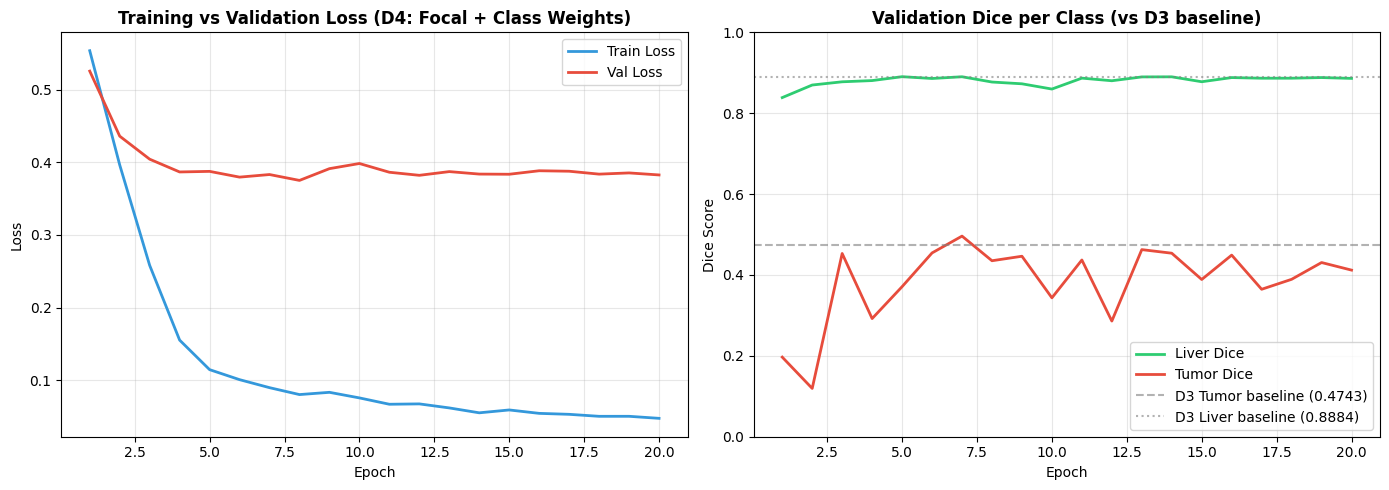

Saved: training_curves_d4.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss (D4: Focal + Class Weights)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_liver_dice'], label='Liver Dice', color='#2ecc71', linewidth=2)
axes[1].plot(epochs, history['val_tumor_dice'], label='Tumor Dice', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0.4743, color='gray', linestyle='--', alpha=0.6, label='D3 Tumor baseline (0.4743)')
axes[1].axhline(y=0.8884, color='gray', linestyle=':',  alpha=0.6, label='D3 Liver baseline (0.8884)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice per Class (vs D3 baseline)', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_d4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_d4.png')

## 12. Qualitative Predictions

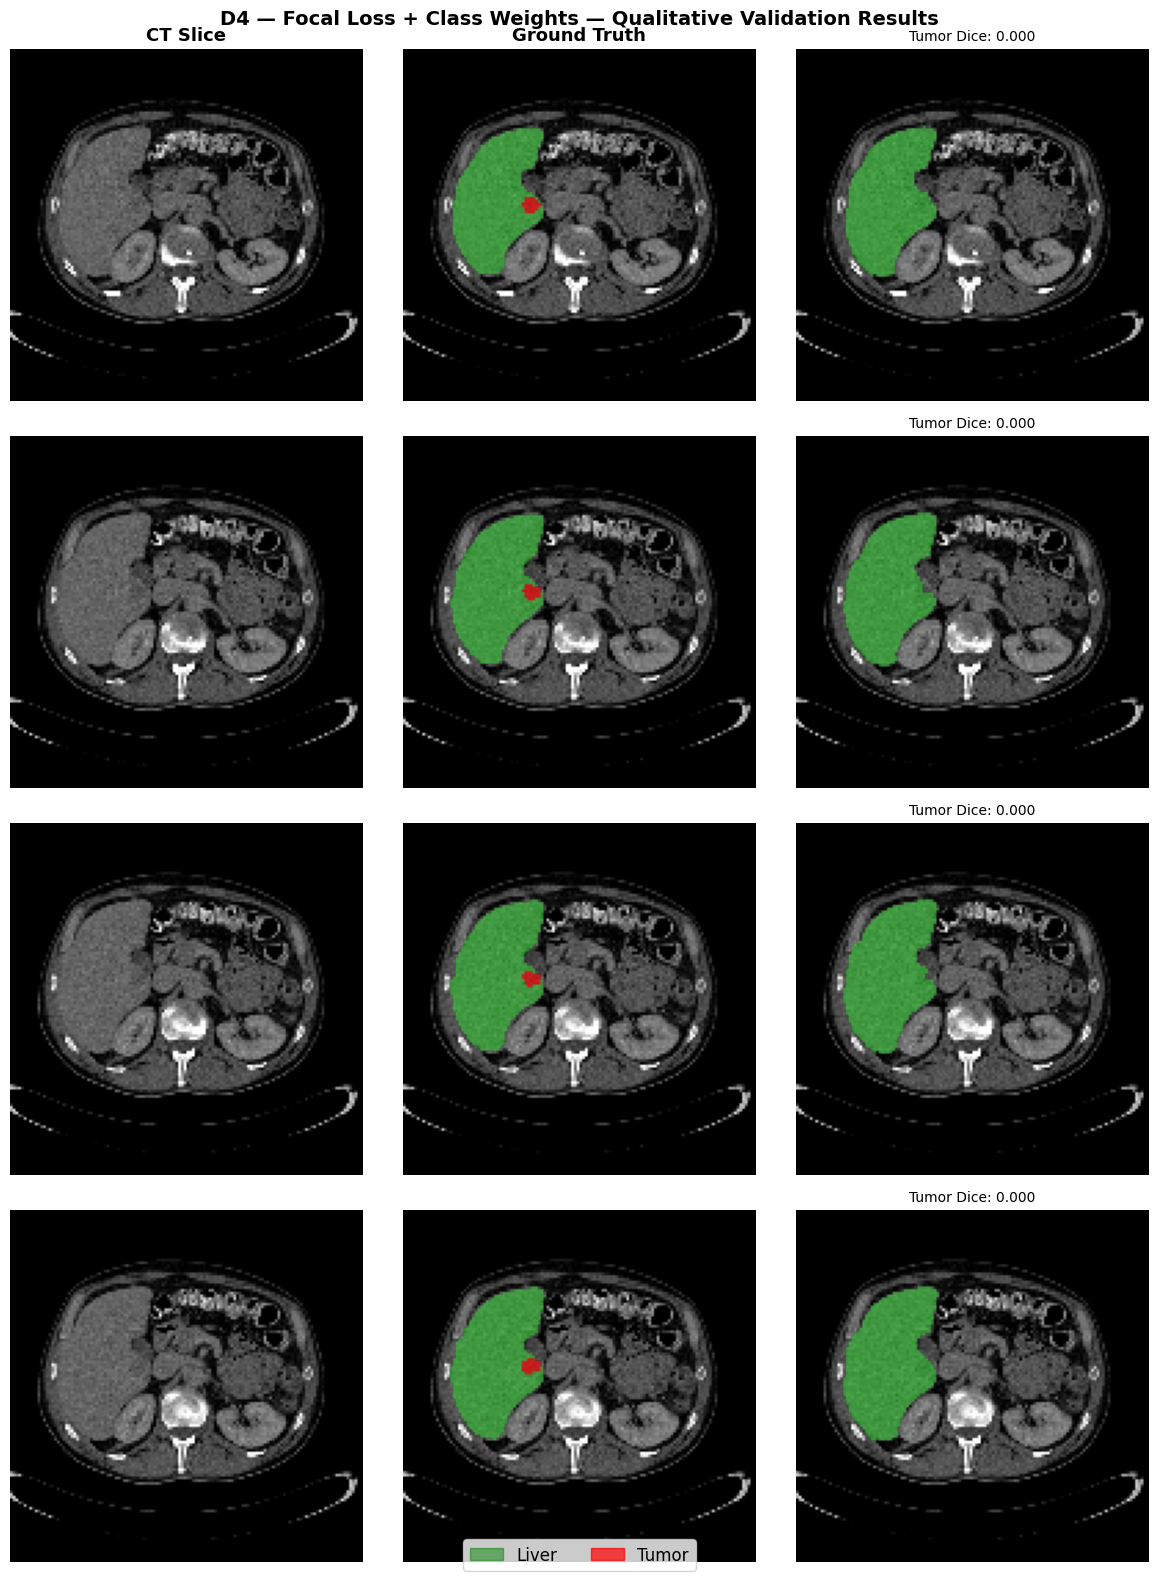

Saved: qualitative_d4.png


In [16]:
#4 validation slices with real tumors, render CT/GT/Prediction side-by-side with per-sample Dice
model.eval()
samples = []

with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)
        preds     = model(ct_batch)
        pred_cls  = preds.argmax(dim=1)

        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if np.sum(gt == 2) > 30:
                samples.append({
                    'ct':   ct_batch[i, 0].cpu().numpy(),
                    'gt':   gt,
                    'pred': pred_cls[i].cpu().numpy()
                })
        if len(samples) >= 4:
            break

def make_overlay(ct, seg):
    overlay = np.zeros((*ct.shape, 4))
    overlay[seg == 1] = [0, 1, 0, 0.35]
    overlay[seg == 2] = [1, 0, 0, 0.65]
    return overlay

n_show = min(4, len(samples))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1: axes = [axes]

for col, title in enumerate(['CT Slice', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(title, fontsize=13, fontweight='bold')

for row, s in enumerate(samples[:n_show]):
    ct, gt, pred = s['ct'], s['gt'], s['pred']

    axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][0].axis('off')

    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(make_overlay(ct, gt).transpose(1, 0, 2), origin='lower')
    axes[row][1].axis('off')

    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(make_overlay(ct, pred).transpose(1, 0, 2), origin='lower')

    p_t = (pred == 2).astype(float)
    g_t = (gt   == 2).astype(float)
    inter = (p_t * g_t).sum()
    denom = p_t.sum() + g_t.sum()
    sample_dice = (2 * inter / denom) if denom > 0 else 1.0
    axes[row][2].set_title(f'Tumor Dice: {sample_dice:.3f}', fontsize=10)
    axes[row][2].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=12)
plt.suptitle('D4 — Focal Loss + Class Weights — Qualitative Validation Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qualitative_d4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qualitative_d4.png')